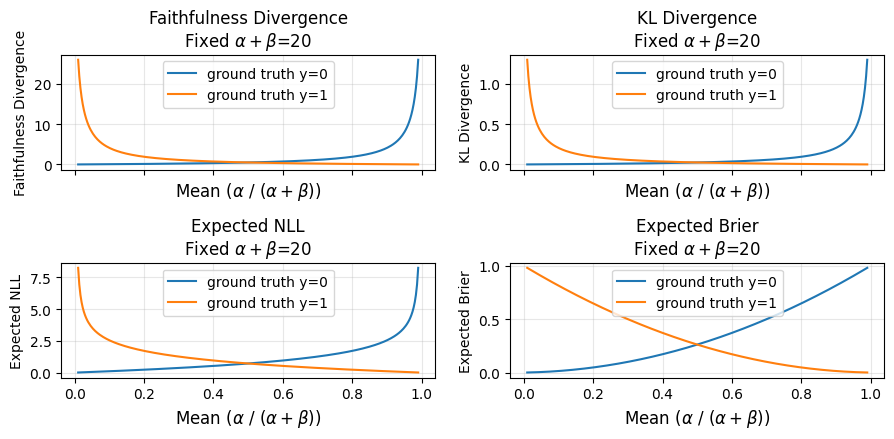

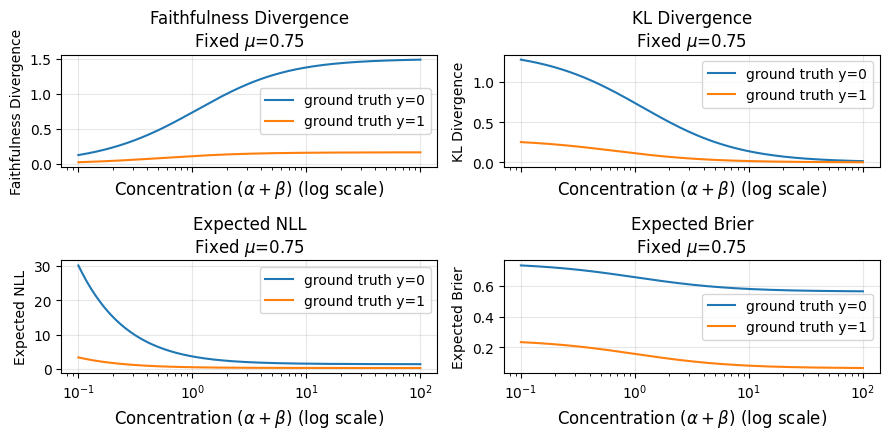

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import betaln, psi


def kl_beta(a_post, b_post, a_prior, b_prior):
    return (
        betaln(a_prior, b_prior) - betaln(a_post, b_post)
        + (a_post - a_prior) * psi(a_post)
        + (b_post - b_prior) * psi(b_post)
        + (a_prior + b_prior - a_post - b_post) * psi(a_post + b_post)
    )


def kl(a, b, y):
    a_post = a + y
    b_post = b + (1 - y)
    return kl_beta(a_post, b_post, a, b)


def faithfulness_divergence(a, b, y):
    return (a + b + 1e-8) * kl(a, b, y)


def expected_brier_score(a, b, y):
    mu = a / (a + b)
    e_p2 = (a * (a + 1.0)) / ((a + b) * (a + b + 1.0))
    return e_p2 - 2.0 * y * mu + y ** 2


def expected_nll(a, b, y):
    if y == 1:
        return psi(a + b) - psi(a)
    return psi(a + b) - psi(b)


metrics = {
    "Faithfulness Divergence": faithfulness_divergence,
    "KL Divergence": kl,
    "Expected NLL": expected_nll,
    "Expected Brier": expected_brier_score,
}


def alpha_beta_from_mean_conc(mean, conc):
    a = mean * conc
    b = (1.0 - mean) * conc
    return a, b


def _central_diff(values, grid):
    dv = np.gradient(values, grid)
    return dv


# ---------------------------------------------------------------------------
# Figure 1: Fix concentration, vary mean
# ---------------------------------------------------------------------------
mean_vals = np.linspace(0.01, 0.99, 300)
fixed_conc = 20.0

fig1, axes1 = plt.subplots(2, 2, figsize=(9, 4.5), sharex=True)
axes1 = axes1.ravel()

for ax, (title, metric_fn) in zip(axes1, metrics.items()):
    for y_value in [0, 1]:
        a, b = alpha_beta_from_mean_conc(mean_vals, fixed_conc)
        err = metric_fn(a, b, y_value)
        ax.plot(mean_vals, err, label=f"ground truth y={y_value}")
    ax.set_title(f"{title}\nFixed $\\alpha + \\beta$={fixed_conc:g}")
    ax.set_xlabel("Mean ($\\alpha$ / ($\\alpha + \\beta$))", fontsize=12)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig1.tight_layout()
fig1.savefig("figs/fd_ablation_theoretical_fixed_conc.pdf", dpi=300, bbox_inches="tight")


# ---------------------------------------------------------------------------
# Figure 2: Fix mean, vary concentration
# ---------------------------------------------------------------------------
conc_vals = np.logspace(-1, 2, 300)  # 0.1 to 100
fixed_mean = 0.75

fig2, axes2 = plt.subplots(2, 2, figsize=(9, 4.5), sharex=True)
axes2 = axes2.ravel()

for ax, (title, metric_fn) in zip(axes2, metrics.items()):
    for y_value in [0, 1]:
        a, b = alpha_beta_from_mean_conc(fixed_mean, conc_vals)
        err = metric_fn(a, b, y_value)
        ax.plot(conc_vals, err, label=f"ground truth y={y_value}")
    ax.set_title(f"{title}\nFixed $\\mu$={fixed_mean:g}")
    ax.set_xlabel("Concentration ($\\alpha + \\beta$) (log scale)", fontsize=12)
    ax.set_ylabel(title)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig2.tight_layout()
fig2.savefig("figs/fd_ablation_theoretical_fixed_mean.pdf", dpi=300, bbox_inches="tight")